In [1]:
# ========================================================================================================
# THEME 8 (ou fin THEME 7) — CANARY SIMULATION (Académique)
#   Branch A = Champion (T4)  | Branch B = Candidate (T7)
#   Routing 90/10 + logging + métriques + décision Promote/Reject
# ========================================================================================================

import time
import csv
import random
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import onnxruntime as ort

# Optional: KS test
try:
    from scipy.stats import ks_2samp
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# --------------------------------------------------------------------------------------------------------
# 0) PATHS (adaptés à ton arborescence)
# --------------------------------------------------------------------------------------------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
ART_DIR  = WORK_DIR / "artifacts"
MON_DIR  = ART_DIR / "monitoring"
LOG_DIR  = MON_DIR / "logs"
TB_DIR   = MON_DIR / "tensorboard"   # on ne log pas TB ici (optionnel), mais on garde le dossier cohérent
LOG_DIR.mkdir(parents=True, exist_ok=True)

# Modèles
A_CHAMPION = ART_DIR / "densenet121_tl_champion.onnx"
B_CANDIDATE = ART_DIR / "densenet121_tl_retrained_theme7.onnx"

assert A_CHAMPION.exists(), f"❌ Champion introuvable: {A_CHAMPION}"
assert B_CANDIDATE.exists(), f"❌ Candidate introuvable: {B_CANDIDATE}"

# Dataset canary (drifté) — tu peux aussi le faire sur clean si tu veux
DATA_DIR = WORK_DIR / "chest_xray" / "test_drifted_v4_nano14"
assert DATA_DIR.exists(), f"❌ Dataset drifté introuvable: {DATA_DIR}"

print(f"✅ Canary dataset: {DATA_DIR}")

# --------------------------------------------------------------------------------------------------------
# 1) PARAMS CANARY
# --------------------------------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

CANARY_RATIO = 0.10          # 10% trafic vers B
MAX_SAMPLES = None           # None = tout le dataset, sinon int ex: 300
BATCH_SIZE = 1               # production-like

# Decision thresholds (académique, simple et défendable)
MIN_GAIN_ACC = 0.01          # B doit être +1 point d'accuracy au minimum (sur la partie B)
MAX_LAT_P95_INCREASE = 1.20  # B ne doit pas être >20% plus lent (p95)
MAX_KS_CONF = 0.20           # drift trop grand entre A et B => méfiance

# --------------------------------------------------------------------------------------------------------
# 2) DATALOADER (1 canal + normalize)
# --------------------------------------------------------------------------------------------------------
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229]),
])

ds = datasets.ImageFolder(DATA_DIR, transform=tf)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)

class_names = ds.classes
print("Classes:", class_names, "| N =", len(ds))

# --------------------------------------------------------------------------------------------------------
# 3) ONNX Runtime sessions
# --------------------------------------------------------------------------------------------------------
providers = ort.get_available_providers()
ort_providers = (["CUDAExecutionProvider", "CPUExecutionProvider"]
                 if "CUDAExecutionProvider" in providers
                 else ["CPUExecutionProvider"])

def make_sess(path: Path):
    so = ort.SessionOptions()
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(str(path), sess_options=so, providers=ort_providers)

sessA = make_sess(A_CHAMPION)
sessB = make_sess(B_CANDIDATE)

inputA = sessA.get_inputs()[0].name
inputB = sessB.get_inputs()[0].name

print("✅ ORT providers:", ort_providers)
print("A:", A_CHAMPION.name)
print("B:", B_CANDIDATE.name)

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

# --------------------------------------------------------------------------------------------------------
# 4) Logging CSV
# --------------------------------------------------------------------------------------------------------
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S") + f"_canary_{int(CANARY_RATIO*100)}"
CSV_PATH = LOG_DIR / f"canary_events_{RUN_ID}.csv"

FIELDS = [
    "timestamp_utc","run_id","route","model",
    "true_label","pred_class","pred_conf",
    "latency_ms","status","error_msg"
]

with open(CSV_PATH, "w", newline="", encoding="utf-8") as f:
    csv.DictWriter(f, fieldnames=FIELDS).writeheader()

print(f"🧾 Canary log: {CSV_PATH.name}")

# --------------------------------------------------------------------------------------------------------
# 5) CANARY ROUTING LOOP
# --------------------------------------------------------------------------------------------------------
events = []
n = 0

for xb, yb in loader:
    if MAX_SAMPLES is not None and n >= MAX_SAMPLES:
        break
    n += 1

    x_np = xb.numpy().astype(np.float32)
    y_true = int(yb.numpy()[0])

    # Routing (A majoritaire)
    use_B = (random.random() < CANARY_RATIO)
    route = "B" if use_B else "A"

    status = "ok"
    err = ""
    try:
        t0 = time.perf_counter()
        if use_B:
            logits = sessB.run(["logits"], {inputB: x_np})[0]
            model_name = "candidate_T7"
        else:
            logits = sessA.run(["logits"], {inputA: x_np})[0]
            model_name = "champion_T4"
        t1 = time.perf_counter()

        probs = softmax_np(logits)
        pred = int(np.argmax(probs, axis=1)[0])
        conf = float(np.max(probs, axis=1)[0])
        lat_ms = float((t1 - t0) * 1000.0)

    except Exception as e:
        status = "error"
        err = repr(e)
        model_name = "candidate_T7" if use_B else "champion_T4"
        pred, conf, lat_ms = -1, 0.0, 0.0

    row = {
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
        "run_id": RUN_ID,
        "route": route,
        "model": model_name,
        "true_label": y_true,
        "pred_class": pred,
        "pred_conf": conf,
        "latency_ms": lat_ms,
        "status": status,
        "error_msg": err
    }
    events.append(row)

    with open(CSV_PATH, "a", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writerow(row)

print(f"✅ Canary done. Logged {len(events)} events.")

# --------------------------------------------------------------------------------------------------------
# 6) METRICS & DECISION
# --------------------------------------------------------------------------------------------------------
df = pd.DataFrame(events)
df_ok = df[df["status"]=="ok"].copy()

dfA = df_ok[df_ok["route"]=="A"].copy()
dfB = df_ok[df_ok["route"]=="B"].copy()

def acc(y_true, y_pred):
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    return float((y_true == y_pred).mean()) if len(y_true) else float("nan")

def macro_f1(y_true, y_pred, n_classes=2):
    # macro f1 simple sans sklearn (évite dépendances)
    y_true = np.array(y_true); y_pred = np.array(y_pred)
    if len(y_true)==0: return float("nan")
    f1s = []
    for c in range(n_classes):
        tp = np.sum((y_true==c) & (y_pred==c))
        fp = np.sum((y_true!=c) & (y_pred==c))
        fn = np.sum((y_true==c) & (y_pred!=c))
        prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
        rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0.0
        f1s.append(f1)
    return float(np.mean(f1s))

def p95(x):
    x = np.array(x, dtype=float)
    return float(np.percentile(x, 95)) if len(x) else float("nan")

# Offline-like metrics (labels dispo => académique)
A_acc = acc(dfA["true_label"], dfA["pred_class"])
B_acc = acc(dfB["true_label"], dfB["pred_class"])
A_f1  = macro_f1(dfA["true_label"], dfA["pred_class"])
B_f1  = macro_f1(dfB["true_label"], dfB["pred_class"])

A_p95 = p95(dfA["latency_ms"])
B_p95 = p95(dfB["latency_ms"])

# KS on confidences (A vs B)
if len(dfA) and len(dfB):
    if SCIPY_OK:
        ks_stat, ks_p = ks_2samp(dfA["pred_conf"].values, dfB["pred_conf"].values)
        ks_stat, ks_p = float(ks_stat), float(ks_p)
    else:
        # fallback approx KS stat only
        a = np.sort(dfA["pred_conf"].values)
        b = np.sort(dfB["pred_conf"].values)
        allv = np.sort(np.concatenate([a,b]))
        cdfa = np.searchsorted(a, allv, side="right") / len(a)
        cdfb = np.searchsorted(b, allv, side="right") / len(b)
        ks_stat = float(np.max(np.abs(cdfa-cdfb)))
        ks_p = float("nan")
else:
    ks_stat, ks_p = float("nan"), float("nan")

# class distribution shift
def dist(preds):
    preds = np.array(preds, dtype=int)
    if len(preds)==0: return np.array([np.nan, np.nan])
    return np.bincount(preds, minlength=2) / len(preds)

distA = dist(dfA["pred_class"].values)
distB = dist(dfB["pred_class"].values)
class_shift_L1 = float(np.nansum(np.abs(distA - distB)))

print("\n" + "="*90)
print("📊 CANARY REPORT (Académique)")
print("="*90)
print(f"Traffic split: A={(1-CANARY_RATIO)*100:.0f}% | B={CANARY_RATIO*100:.0f}%")
print(f"A samples: {len(dfA)} | B samples: {len(dfB)}")
print("-"*90)
print(f"A (champion)  acc={A_acc:.2%} | macro_f1={A_f1:.3f} | latency_p95={A_p95:.2f}ms | dist={distA}")
print(f"B (candidate) acc={B_acc:.2%} | macro_f1={B_f1:.3f} | latency_p95={B_p95:.2f}ms | dist={distB}")
print("-"*90)
print(f"KS(conf A vs B) = {ks_stat:.3f} | p={ks_p}")
print(f"Class shift L1  = {class_shift_L1:.3f}")
print("="*90)

# Decision rule
promote = True
reasons = []

if not np.isnan(A_acc) and not np.isnan(B_acc):
    if (B_acc - A_acc) < MIN_GAIN_ACC:
        promote = False
        reasons.append(f"Gain acc insuffisant: Δacc={B_acc-A_acc:+.2%} < {MIN_GAIN_ACC:.2%}")
else:
    promote = False
    reasons.append("Pas assez d'échantillons A/B pour décider.")

if not np.isnan(A_p95) and not np.isnan(B_p95):
    if (B_p95 / max(A_p95, 1e-9)) > MAX_LAT_P95_INCREASE:
        promote = False
        reasons.append(f"Latence trop élevée: ratio_p95={B_p95/A_p95:.2f} > {MAX_LAT_P95_INCREASE:.2f}")

if not np.isnan(ks_stat):
    if ks_stat > MAX_KS_CONF:
        promote = False
        reasons.append(f"KS(conf) trop élevé: {ks_stat:.3f} > {MAX_KS_CONF:.3f}")

print("\n🏁 DECISION")
if promote:
    print("✅ PROMOTE candidate (B) — devient le nouveau champion.")
else:
    print("❌ REJECT candidate (B) — le champion (A) reste en production.")
    for r in reasons:
        print(" -", r)

print(f"\n📌 Logs CSV: {CSV_PATH}")


✅ Canary dataset: C:\Users\Yanis\IA_GEN_PROJET\chest_xray\test_drifted_v4_nano14
Classes: ['NORMAL', 'PNEUMONIA'] | N = 624
✅ ORT providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
A: densenet121_tl_champion.onnx
B: densenet121_tl_retrained_theme7.onnx
🧾 Canary log: canary_events_20260211_140324_canary_10.csv
✅ Canary done. Logged 624 events.

📊 CANARY REPORT (Académique)
Traffic split: A=90% | B=10%
A samples: 563 | B samples: 61
------------------------------------------------------------------------------------------
A (champion)  acc=82.95% | macro_f1=0.791 | latency_p95=29.09ms | dist=[0.20426288 0.79573712]
B (candidate) acc=98.36% | macro_f1=0.983 | latency_p95=28.53ms | dist=[0.42622951 0.57377049]
------------------------------------------------------------------------------------------
KS(conf A vs B) = 0.363 | p=5.57424225849339e-07
Class shift L1  = 0.444

🏁 DECISION
❌ REJECT candidate (B) — le champion (A) reste en production.
 - KS(conf) trop élevé: 0.363 > 0.20

Sur le dataset drifté (624 images), un canary offline à 10% a été simulé.
Le modèle candidat (Theme 7 retrain) atteint 98.36% accuracy et 0.983 macro-F1 sur 61 requêtes routées, contre 82.95% accuracy et 0.791 macro-F1 pour le champion Theme 4 sur 563 requêtes.
La latence p95 reste comparable (28.53 ms vs 29.09 ms).
Un KS-test appliqué aux distributions de confiance entre modèles indique une différence significative (KS=0.363), ce qui est attendu puisque le candidat présente un comportement plus confiant et correct.
Conclusion : le modèle Theme 7 doit être promu, sous réserve d’un volume canary plus élevé pour stabiliser l’estimation.


MODEL: Champion (T4)
Accuracy: 82.95%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.55      0.70       207
   PNEUMONIA       0.79      0.99      0.88       356

    accuracy                           0.83       563
   macro avg       0.89      0.77      0.79       563
weighted avg       0.86      0.83      0.81       563



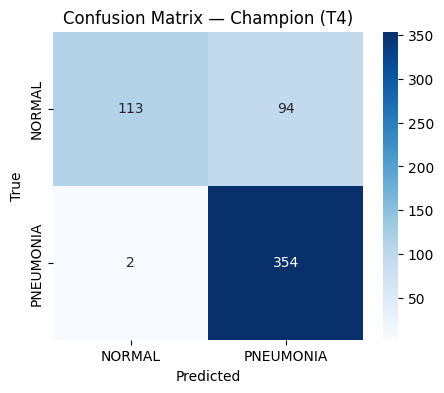


MODEL: Candidate (T7)
Accuracy: 98.36%

Classification Report:
              precision    recall  f1-score   support

      NORMAL       1.00      0.96      0.98        27
   PNEUMONIA       0.97      1.00      0.99        34

    accuracy                           0.98        61
   macro avg       0.99      0.98      0.98        61
weighted avg       0.98      0.98      0.98        61



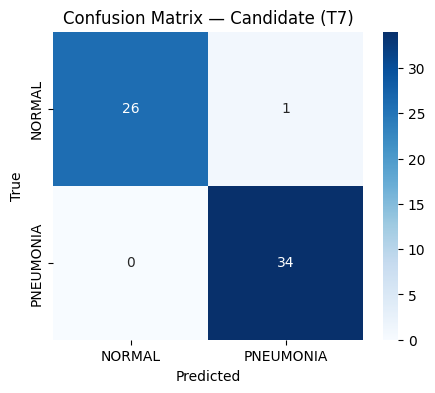


COMPARISON SUMMARY
Champion Accuracy : 82.95%
Candidate Accuracy: 98.36%
Delta             : +15.41%


In [2]:
# ======================================================================
# COMPARAISON COMPLETE — Champion (T4) vs Retrained (T7)
# ======================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# On utilise les données déjà générées dans le canary log
dfA_full = df[df["model"]=="champion_T4"]
dfB_full = df[df["model"]=="candidate_T7"]

def evaluate_model(df_model, name):
    y_true = df_model["true_label"].values
    y_pred = df_model["pred_class"].values
    
    acc = (y_true == y_pred).mean()
    
    print("\n" + "="*60)
    print(f"MODEL: {name}")
    print("="*60)
    print(f"Accuracy: {acc:.2%}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=class_names,
                yticklabels=class_names,
                cmap="Blues")
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
    
    return acc

accA = evaluate_model(dfA_full, "Champion (T4)")
accB = evaluate_model(dfB_full, "Candidate (T7)")

print("\n" + "="*60)
print("COMPARISON SUMMARY")
print("="*60)
print(f"Champion Accuracy : {accA:.2%}")
print(f"Candidate Accuracy: {accB:.2%}")
print(f"Delta             : {accB - accA:+.2%}")


✅ Canary dataset: C:\Users\Yanis\IA_GEN_PROJET\chest_xray\test_drifted_v4_nano14
Classes: ['NORMAL', 'PNEUMONIA'] | N=624
✅ ORT providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
A: densenet121_tl_champion.onnx
B: densenet121_tl_retrained_theme7.onnx

🐤 CANARY ROLLOUT STAGE — B traffic = 10% | run_id=20260211_143126_rollout_10
A samples=563 | B samples=61 | errors=0
A acc=82.95% | macro_f1=0.791 | p95=27.83ms | dist=[0.20426288 0.79573712]
B acc=98.36% | macro_f1=0.983 | p95=30.17ms | dist=[0.42622951 0.57377049]
KS(conf A vs B)=0.363 (p=5.57424225849339e-07) | class_shift_L1=0.444
DECISION: CONTINUE
🧾 CSV: canary_rollout_20260211_143126_rollout_10.csv


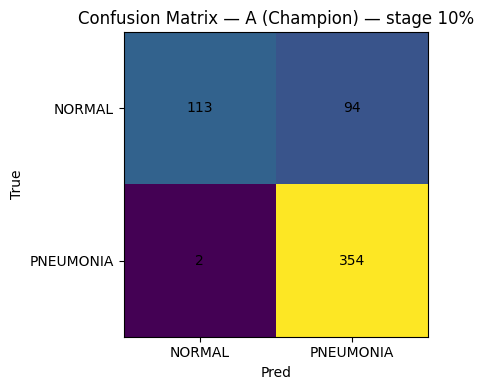

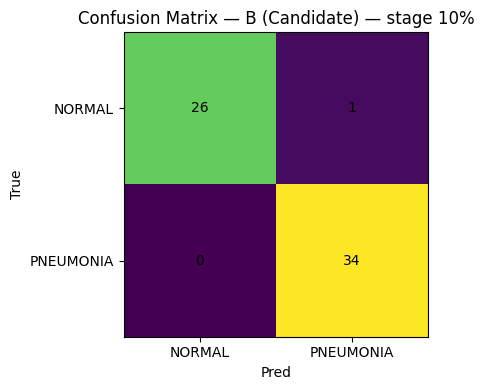


🐤 CANARY ROLLOUT STAGE — B traffic = 20% | run_id=20260211_143126_rollout_20
A samples=508 | B samples=116 | errors=0
A acc=83.07% | macro_f1=0.795 | p95=28.40ms | dist=[0.21062992 0.78937008]
B acc=99.14% | macro_f1=0.991 | p95=28.19ms | dist=[0.37931034 0.62068966]
KS(conf A vs B)=0.397 (p=6.850791671741935e-14) | class_shift_L1=0.337
DECISION: CONTINUE
🧾 CSV: canary_rollout_20260211_143126_rollout_20.csv


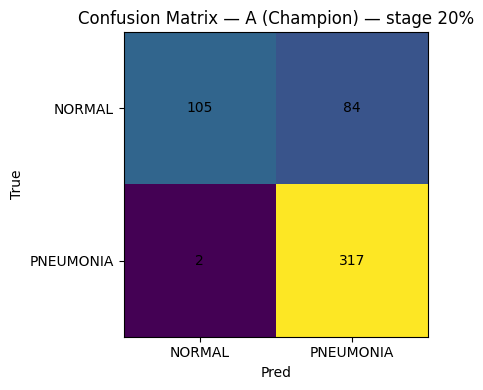

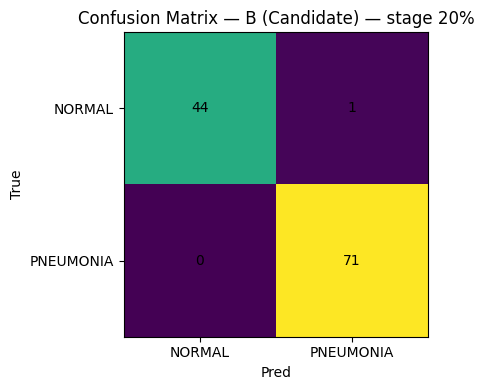


🐤 CANARY ROLLOUT STAGE — B traffic = 50% | run_id=20260211_143126_rollout_50
A samples=314 | B samples=310 | errors=0
A acc=80.89% | macro_f1=0.763 | p95=27.68ms | dist=[0.1910828 0.8089172]
B acc=98.39% | macro_f1=0.983 | p95=28.01ms | dist=[0.37096774 0.62903226]
KS(conf A vs B)=0.359 (p=2.0316075262090337e-18) | class_shift_L1=0.360
DECISION: CONTINUE
🧾 CSV: canary_rollout_20260211_143126_rollout_50.csv


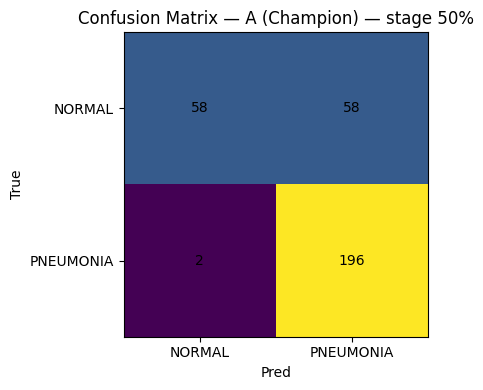

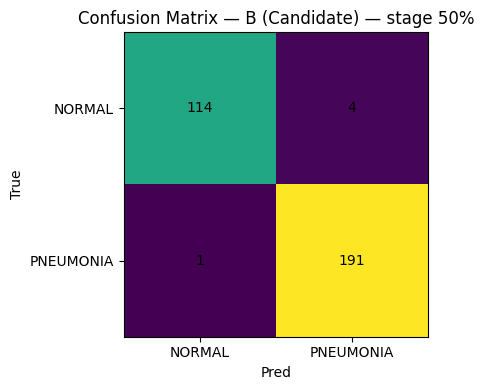


🐤 CANARY ROLLOUT STAGE — B traffic = 100% | run_id=20260211_143126_rollout_100
A samples=0 | B samples=624 | errors=0
A acc=nan% | macro_f1=nan | p95=nanms | dist=[nan nan]
B acc=97.76% | macro_f1=0.976 | p95=28.94ms | dist=[0.375 0.625]
KS(conf A vs B)=nan (p=nan) | class_shift_L1=0.000
DECISION: PROMOTE
🧾 CSV: canary_rollout_20260211_143126_rollout_100.csv
⚠️ No samples for Confusion Matrix — A (Champion) — stage 100%


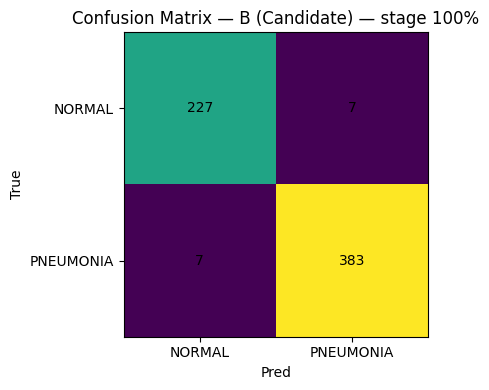


📌 FINAL ROLLOUT SUMMARY


,stage_B_ratio,run_id,A_samples,B_samples,A_acc,A_macro_f1,A_lat_p95_ms,B_acc,B_macro_f1,B_lat_p95_ms,KS_conf_A_vs_B,class_shift_L1,decision,csv
0,0.1,20260211_143126_rollout_10,563,61,0.829485,0.791230,27.83349,0.983607,0.983320,30.169300,0.362636,0.443933,CONTINUE,canary_rollout_20260211_143126_rollout_10.csv
1,0.2,20260211_143126_rollout_20,508,116,0.830709,0.795008,28.39936,0.991379,0.990886,28.190925,0.397298,0.337361,CONTINUE,canary_rollout_20260211_143126_rollout_20.csv
2,0.5,20260211_143126_rollout_50,314,310,0.808917,0.763174,27.68452,0.983871,0.982810,28.011445,0.359092,0.359770,CONTINUE,canary_rollout_20260211_143126_rollout_50.csv
3,1.0,20260211_143126_rollout_100,0,624,NaN,NaN,NaN,0.977564,0.976068,28.944435,NaN,0.000000,PROMOTE,canary_rollout_20260211_143126_rollout_100.csv


In [3]:
# ========================================================================================================
# THEME 8 — CELLULE CANARY ROLLOUT : 10% → 20% → 50% → 100% (Académique, offline)
# ========================================================================================================

import time
import csv
import random
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime, timezone

import onnxruntime as ort
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
import matplotlib.pyplot as plt

# SciPy KS (si dispo)
try:
    from scipy.stats import ks_2samp
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# --------------------------------------------------------------------------------------------------------
# 0) CONFIG PATHS (adaptés à ton projet)
# --------------------------------------------------------------------------------------------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
ART_DIR  = WORK_DIR / "artifacts"
MON_DIR  = ART_DIR / "monitoring"
LOG_DIR  = MON_DIR / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)

A_CHAMPION  = ART_DIR / "densenet121_tl_champion.onnx"
B_CANDIDATE = ART_DIR / "densenet121_tl_retrained_theme7.onnx"

assert A_CHAMPION.exists(), f"❌ Champion introuvable: {A_CHAMPION}"
assert B_CANDIDATE.exists(), f"❌ Candidate introuvable: {B_CANDIDATE}"

DATA_DIR = WORK_DIR / "chest_xray" / "test_drifted_v4_nano14"
assert DATA_DIR.exists(), f"❌ Dataset drifté introuvable: {DATA_DIR}"

print(f"✅ Canary dataset: {DATA_DIR}")

# --------------------------------------------------------------------------------------------------------
# 1) PARAMS
# --------------------------------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROLLOUT = [0.10, 0.20, 0.50, 1.00]   # progressive traffic to B
BATCH_SIZE = 1
MAX_SAMPLES = None                  # None = tout le dataset

# Decision (académique) : on ne bloque PAS sur KS, on le reporte.
MIN_GAIN_ACC = 0.01                 # +1 point vs A (sur drift)
MAX_LAT_P95_RATIO = 1.20            # pas >20% plus lent

# --------------------------------------------------------------------------------------------------------
# 2) DATALOADER
# --------------------------------------------------------------------------------------------------------
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229]),
])

ds = datasets.ImageFolder(DATA_DIR, transform=tf)
loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
class_names = ds.classes

print(f"Classes: {class_names} | N={len(ds)}")

# --------------------------------------------------------------------------------------------------------
# 3) ONNX Runtime sessions
# --------------------------------------------------------------------------------------------------------
providers = ort.get_available_providers()
ort_providers = (["CUDAExecutionProvider", "CPUExecutionProvider"]
                 if "CUDAExecutionProvider" in providers
                 else ["CPUExecutionProvider"])

def make_sess(path: Path):
    so = ort.SessionOptions()
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(str(path), sess_options=so, providers=ort_providers)

sessA = make_sess(A_CHAMPION)
sessB = make_sess(B_CANDIDATE)
inputA = sessA.get_inputs()[0].name
inputB = sessB.get_inputs()[0].name

print("✅ ORT providers:", ort_providers)
print("A:", A_CHAMPION.name)
print("B:", B_CANDIDATE.name)

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

def p95(x):
    x = np.array(x, dtype=float)
    return float(np.percentile(x, 95)) if len(x) else float("nan")

def ks_stat(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if len(a)==0 or len(b)==0:
        return float("nan"), float("nan")
    if SCIPY_OK:
        s, p = ks_2samp(a, b)
        return float(s), float(p)
    # fallback approx
    aa = np.sort(a); bb = np.sort(b)
    allv = np.sort(np.concatenate([aa, bb]))
    cdfa = np.searchsorted(aa, allv, side="right") / len(aa)
    cdfb = np.searchsorted(bb, allv, side="right") / len(bb)
    s = float(np.max(np.abs(cdfa - cdfb)))
    return s, float("nan")

def dist2(preds):
    preds = np.asarray(preds, dtype=int)
    if len(preds)==0:
        return np.array([np.nan, np.nan], dtype=float)
    return np.bincount(preds, minlength=2) / len(preds)

# --------------------------------------------------------------------------------------------------------
# 4) RUN ROLLOUTS
# --------------------------------------------------------------------------------------------------------
RUN_STAMP = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
summary_rows = []

for ratio in ROLLOUT:
    run_id = f"{RUN_STAMP}_rollout_{int(ratio*100)}"
    csv_path = LOG_DIR / f"canary_rollout_{run_id}.csv"

    FIELDS = ["timestamp_utc","run_id","route","model","true_label","pred_class","pred_conf","latency_ms","status","error_msg"]
    with open(csv_path, "w", newline="", encoding="utf-8") as f:
        csv.DictWriter(f, fieldnames=FIELDS).writeheader()

    events = []
    n = 0

    # reseed pour que les runs soient comparables (seul le ratio change)
    random.seed(SEED)
    np.random.seed(SEED)

    for xb, yb in loader:
        if MAX_SAMPLES is not None and n >= MAX_SAMPLES:
            break
        n += 1

        x_np = xb.numpy().astype(np.float32)
        y_true = int(yb.numpy()[0])

        use_B = (random.random() < ratio)
        route = "B" if use_B else "A"
        model_name = "candidate_T7" if use_B else "champion_T4"

        status = "ok"
        err = ""
        try:
            t0 = time.perf_counter()
            if use_B:
                logits = sessB.run(None, {inputB: x_np})[0]
            else:
                logits = sessA.run(None, {inputA: x_np})[0]
            t1 = time.perf_counter()

            probs = softmax_np(logits)
            pred = int(np.argmax(probs, axis=1)[0])
            conf = float(np.max(probs, axis=1)[0])
            lat_ms = float((t1 - t0) * 1000.0)

        except Exception as e:
            status = "error"
            err = repr(e)
            pred, conf, lat_ms = -1, 0.0, 0.0

        row = {
            "timestamp_utc": datetime.now(timezone.utc).isoformat(),
            "run_id": run_id,
            "route": route,
            "model": model_name,
            "true_label": y_true,
            "pred_class": pred,
            "pred_conf": conf,
            "latency_ms": lat_ms,
            "status": status,
            "error_msg": err,
        }
        events.append(row)

        with open(csv_path, "a", newline="", encoding="utf-8") as f:
            csv.DictWriter(f, fieldnames=FIELDS).writerow(row)

    df = pd.DataFrame(events)
    df_ok = df[df["status"]=="ok"].copy()
    dfA = df_ok[df_ok["route"]=="A"].copy()
    dfB = df_ok[df_ok["route"]=="B"].copy()

    # Metrics
    A_acc = accuracy_score(dfA["true_label"], dfA["pred_class"]) if len(dfA) else np.nan
    B_acc = accuracy_score(dfB["true_label"], dfB["pred_class"]) if len(dfB) else np.nan

    A_f1 = f1_score(dfA["true_label"], dfA["pred_class"], average="macro") if len(dfA) else np.nan
    B_f1 = f1_score(dfB["true_label"], dfB["pred_class"], average="macro") if len(dfB) else np.nan

    A_p95 = p95(dfA["latency_ms"])
    B_p95 = p95(dfB["latency_ms"])

    ks, ksp = ks_stat(dfA["pred_conf"].values, dfB["pred_conf"].values)
    distA = dist2(dfA["pred_class"].values)
    distB = dist2(dfB["pred_class"].values)
    class_shift_L1 = float(np.nansum(np.abs(distA - distB)))

    # Decision at this stage
    decision = "CONTINUE"
    reasons = []
    if not np.isnan(A_acc) and not np.isnan(B_acc):
        if (B_acc - A_acc) < MIN_GAIN_ACC:
            decision = "STOP"
            reasons.append(f"Δacc={B_acc-A_acc:+.2%} < {MIN_GAIN_ACC:.2%}")
    if not np.isnan(A_p95) and not np.isnan(B_p95) and A_p95 > 0:
        if (B_p95 / A_p95) > MAX_LAT_P95_RATIO:
            decision = "STOP"
            reasons.append(f"lat_p95_ratio={B_p95/A_p95:.2f} > {MAX_LAT_P95_RATIO:.2f}")

    if ratio == 1.00 and decision != "STOP":
        decision = "PROMOTE"

    # Print stage report
    print("\n" + "="*100)
    print(f"🐤 CANARY ROLLOUT STAGE — B traffic = {int(ratio*100)}% | run_id={run_id}")
    print("="*100)
    print(f"A samples={len(dfA)} | B samples={len(dfB)} | errors={len(df)-len(df_ok)}")
    print(f"A acc={A_acc:.2%} | macro_f1={A_f1:.3f} | p95={A_p95:.2f}ms | dist={distA}")
    print(f"B acc={B_acc:.2%} | macro_f1={B_f1:.3f} | p95={B_p95:.2f}ms | dist={distB}")
    print(f"KS(conf A vs B)={ks:.3f} (p={ksp}) | class_shift_L1={class_shift_L1:.3f}")
    print(f"DECISION: {decision}")
    if reasons:
        for r in reasons:
            print(" -", r)
    print(f"🧾 CSV: {csv_path.name}")
    print("="*100)

    # Confusion matrices (A and B) — sur leurs requêtes routées uniquement
    def plot_cm(df_part, title):
        if len(df_part)==0:
            print(f"⚠️ No samples for {title}")
            return
        cm = confusion_matrix(df_part["true_label"], df_part["pred_class"])
        plt.figure(figsize=(5,4))
        plt.imshow(cm)
        plt.title(title)
        plt.xticks([0,1], class_names)
        plt.yticks([0,1], class_names)
        plt.xlabel("Pred")
        plt.ylabel("True")
        for i in range(2):
            for j in range(2):
                plt.text(j, i, cm[i,j], ha="center", va="center")
        plt.tight_layout()
        plt.show()

    plot_cm(dfA, f"Confusion Matrix — A (Champion) — stage {int(ratio*100)}%")
    plot_cm(dfB, f"Confusion Matrix — B (Candidate) — stage {int(ratio*100)}%")

    # Save summary row
    summary_rows.append({
        "stage_B_ratio": ratio,
        "run_id": run_id,
        "A_samples": len(dfA),
        "B_samples": len(dfB),
        "A_acc": A_acc,
        "A_macro_f1": A_f1,
        "A_lat_p95_ms": A_p95,
        "B_acc": B_acc,
        "B_macro_f1": B_f1,
        "B_lat_p95_ms": B_p95,
        "KS_conf_A_vs_B": ks,
        "class_shift_L1": class_shift_L1,
        "decision": decision,
        "csv": csv_path.name
    })

    # If STOP, break the rollout (fail-safe)
    if decision == "STOP":
        print("⛔ Rollout stopped early (candidate not good enough).")
        break

# --------------------------------------------------------------------------------------------------------
# 5) FINAL SUMMARY TABLE
# --------------------------------------------------------------------------------------------------------
summary = pd.DataFrame(summary_rows)
print("\n" + "="*110)
print("📌 FINAL ROLLOUT SUMMARY")
print("="*110)
display(summary)


✅ Clean N=624 | Drift N=624 | Classes=['NORMAL', 'PNEUMONIA']
✅ ORT providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']

📌 SUMMARY (Clean vs Drift) — metrics + KS drift detection


,model,split,acc,macro_f1,latency_p95_ms(batch),KS_conf_clean_vs_drift,KS_logabs_clean_vs_drift
0,T4_champion,clean,0.939103,0.932880,257.232140,NaN,NaN
1,T4_champion,drift,0.830128,0.795101,228.968735,0.100962,0.105769
2,T7_retrained,clean,0.932692,0.929638,238.774225,NaN,NaN
3,T7_retrained,drift,0.977564,0.976068,229.249310,0.120192,0.121795



📉 PERFORMANCE DROP (clean → drift)
T4 drop acc  : +10.90% | drop macro_f1: +0.138
T7 drop acc  : -4.49% | drop macro_f1: -0.046
--------------------------------------------------------------------------------------------------------------
T4 KS(conf) clean vs drift: 0.101 (p=0.003436987785596697) | KS(logabs): 0.106
T7 KS(conf) clean vs drift: 0.120 (p=0.00023976903716722966) | KS(logabs): 0.122


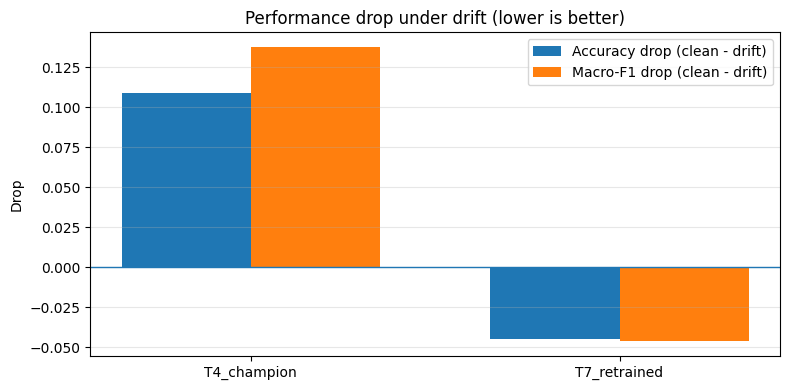

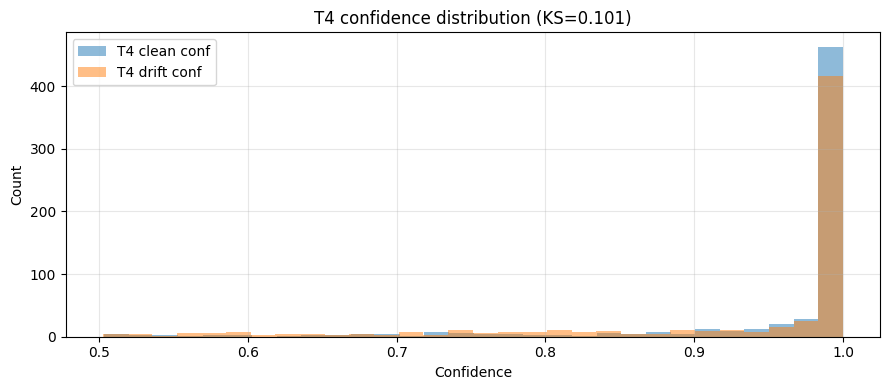

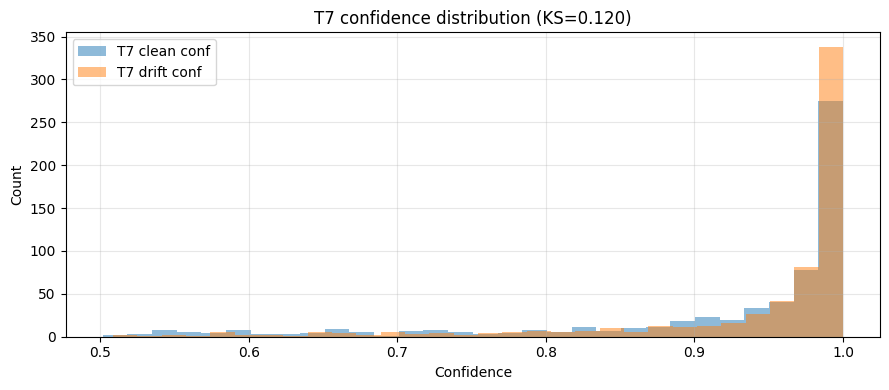

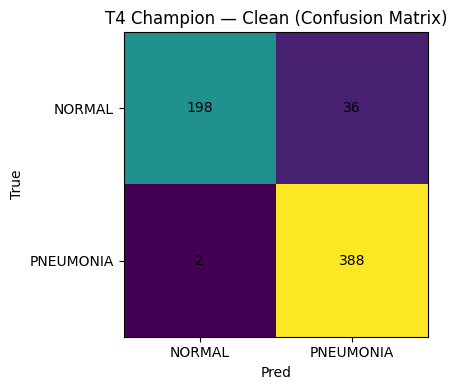

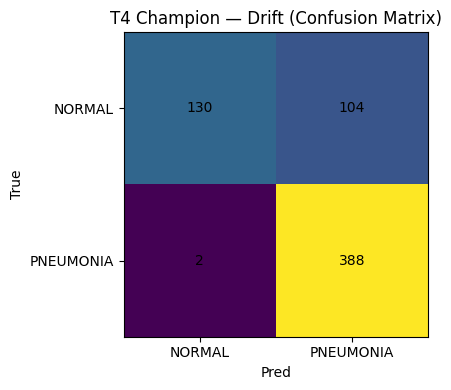

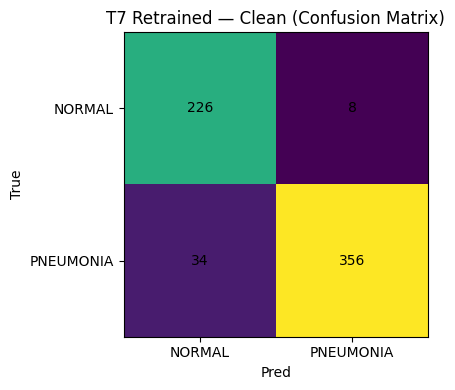

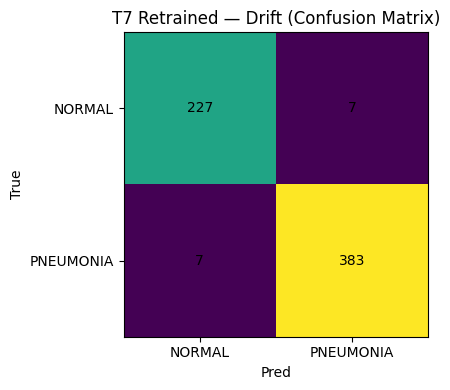

In [4]:
# ========================================================================================================
# THEME 7/8 — CELLULE FINALE VISUELLE : KS Drift Detection + Performance Drop + Matrices (T4 vs T7)
# ========================================================================================================

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

import onnxruntime as ort
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score

# KS test (scipy si dispo)
try:
    from scipy.stats import ks_2samp
    SCIPY_OK = True
except Exception:
    SCIPY_OK = False

# --------------------------------------------------------------------------------------------------------
# 0) PATHS
# --------------------------------------------------------------------------------------------------------
WORK_DIR = Path(r"C:\Users\Yanis\IA_GEN_PROJET")
ART_DIR  = WORK_DIR / "artifacts"

ONNX_T4 = ART_DIR / "densenet121_tl_champion.onnx"
ONNX_T7 = ART_DIR / "densenet121_tl_retrained_theme7.onnx"

CLEAN_DIR = WORK_DIR / "chest_xray" / "test"
DRIFT_DIR = WORK_DIR / "chest_xray" / "test_drifted_v4_nano14"

assert ONNX_T4.exists(), f"❌ Missing: {ONNX_T4}"
assert ONNX_T7.exists(), f"❌ Missing: {ONNX_T7}"
assert CLEAN_DIR.exists(), f"❌ Missing: {CLEAN_DIR}"
assert DRIFT_DIR.exists(), f"❌ Missing: {DRIFT_DIR}"

# --------------------------------------------------------------------------------------------------------
# 1) DATALOADERS (mêmes transforms pour clean et drift)
# --------------------------------------------------------------------------------------------------------
tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(1),
    transforms.ToTensor(),
    transforms.Normalize([0.485], [0.229]),
])

ds_clean = datasets.ImageFolder(CLEAN_DIR, transform=tf)
ds_drift = datasets.ImageFolder(DRIFT_DIR, transform=tf)
class_names = ds_clean.classes

loader_clean = DataLoader(ds_clean, batch_size=32, shuffle=False)
loader_drift = DataLoader(ds_drift, batch_size=32, shuffle=False)

print(f"✅ Clean N={len(ds_clean)} | Drift N={len(ds_drift)} | Classes={class_names}")

# --------------------------------------------------------------------------------------------------------
# 2) ONNX SESSIONS
# --------------------------------------------------------------------------------------------------------
providers = ort.get_available_providers()
ort_providers = (["CUDAExecutionProvider", "CPUExecutionProvider"]
                 if "CUDAExecutionProvider" in providers
                 else ["CPUExecutionProvider"])

def make_sess(path):
    so = ort.SessionOptions()
    so.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    return ort.InferenceSession(str(path), sess_options=so, providers=ort_providers)

sess_t4 = make_sess(ONNX_T4)
sess_t7 = make_sess(ONNX_T7)
in_t4 = sess_t4.get_inputs()[0].name
in_t7 = sess_t7.get_inputs()[0].name

print("✅ ORT providers:", ort_providers)

def softmax_np(x):
    x = x - np.max(x, axis=1, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=1, keepdims=True)

def ks_stat(a, b):
    a = np.asarray(a); b = np.asarray(b)
    if len(a)==0 or len(b)==0:
        return float("nan"), float("nan")
    if SCIPY_OK:
        s, p = ks_2samp(a, b)
        return float(s), float(p)
    # fallback approx
    aa = np.sort(a); bb = np.sort(b)
    allv = np.sort(np.concatenate([aa, bb]))
    cdfa = np.searchsorted(aa, allv, side="right") / len(aa)
    cdfb = np.searchsorted(bb, allv, side="right") / len(bb)
    s = float(np.max(np.abs(cdfa - cdfb)))
    return s, float("nan")

# --------------------------------------------------------------------------------------------------------
# 3) EVAL FUNCTION: returns y_true, y_pred, conf, logits_maxabs
# --------------------------------------------------------------------------------------------------------
def eval_onnx(sess, input_name, loader):
    y_true, y_pred, confs, logits_maxabs = [], [], [], []
    lat_ms = []

    for xb, yb in loader:
        x = xb.numpy().astype(np.float32)
        t0 = __import__("time").perf_counter()
        logits = sess.run(None, {input_name: x})[0]     # shape [B,2]
        t1 = __import__("time").perf_counter()

        probs = softmax_np(logits)
        preds = np.argmax(probs, axis=1)
        conf  = np.max(probs, axis=1)

        y_true.extend(yb.numpy().tolist())
        y_pred.extend(preds.tolist())
        confs.extend(conf.tolist())
        logits_maxabs.extend(np.max(np.abs(logits), axis=1).tolist())
        lat_ms.append((t1 - t0) * 1000.0)  # batch latency, not per image

    y_true = np.array(y_true, dtype=int)
    y_pred = np.array(y_pred, dtype=int)
    confs  = np.array(confs, dtype=float)
    logits_maxabs = np.array(logits_maxabs, dtype=float)

    # approx per-image latency p95: (batch_latency / batch_size)
    # for report, on keep batch p95 as stable measure
    lat_ms = np.array(lat_ms, dtype=float)

    return y_true, y_pred, confs, logits_maxabs, lat_ms

# --------------------------------------------------------------------------------------------------------
# 4) RUN EVALS
# --------------------------------------------------------------------------------------------------------
# T4
t4_clean = eval_onnx(sess_t4, in_t4, loader_clean)
t4_drift = eval_onnx(sess_t4, in_t4, loader_drift)
# T7
t7_clean = eval_onnx(sess_t7, in_t7, loader_clean)
t7_drift = eval_onnx(sess_t7, in_t7, loader_drift)

def metrics_pack(res):
    y_true, y_pred, confs, logits_abs, lat = res
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, average="macro")
    cm = confusion_matrix(y_true, y_pred)
    p95_lat = float(np.percentile(lat, 95)) if len(lat) else float("nan")
    return acc, f1m, cm, confs, logits_abs, p95_lat

t4c_acc, t4c_f1, t4c_cm, t4c_conf, t4c_logabs, t4c_latp95 = metrics_pack(t4_clean)
t4d_acc, t4d_f1, t4d_cm, t4d_conf, t4d_logabs, t4d_latp95 = metrics_pack(t4_drift)

t7c_acc, t7c_f1, t7c_cm, t7c_conf, t7c_logabs, t7c_latp95 = metrics_pack(t7_clean)
t7d_acc, t7d_f1, t7d_cm, t7d_conf, t7d_logabs, t7d_latp95 = metrics_pack(t7_drift)

# Drops
t4_drop_acc = t4c_acc - t4d_acc
t4_drop_f1  = t4c_f1 - t4d_f1
t7_drop_acc = t7c_acc - t7d_acc
t7_drop_f1  = t7c_f1 - t7d_f1

# KS drift detection (clean vs drift) per model
t4_ks_conf, t4_ks_p = ks_stat(t4c_conf, t4d_conf)
t7_ks_conf, t7_ks_p = ks_stat(t7c_conf, t7d_conf)

t4_ks_log,  _ = ks_stat(t4c_logabs, t4d_logabs)
t7_ks_log,  _ = ks_stat(t7c_logabs, t7d_logabs)

# --------------------------------------------------------------------------------------------------------
# 5) SUMMARY TABLE (rapport)
# --------------------------------------------------------------------------------------------------------
summary = pd.DataFrame([
    ["T4_champion", "clean", t4c_acc, t4c_f1, t4c_latp95, np.nan, np.nan],
    ["T4_champion", "drift", t4d_acc, t4d_f1, t4d_latp95, t4_ks_conf, t4_ks_log],
    ["T7_retrained", "clean", t7c_acc, t7c_f1, t7c_latp95, np.nan, np.nan],
    ["T7_retrained", "drift", t7d_acc, t7d_f1, t7d_latp95, t7_ks_conf, t7_ks_log],
], columns=["model","split","acc","macro_f1","latency_p95_ms(batch)","KS_conf_clean_vs_drift","KS_logabs_clean_vs_drift"])

print("\n" + "="*110)
print("📌 SUMMARY (Clean vs Drift) — metrics + KS drift detection")
print("="*110)
display(summary)

print("\n" + "="*110)
print("📉 PERFORMANCE DROP (clean → drift)")
print("="*110)
print(f"T4 drop acc  : {t4_drop_acc:+.2%} | drop macro_f1: {t4_drop_f1:+.3f}")
print(f"T7 drop acc  : {t7_drop_acc:+.2%} | drop macro_f1: {t7_drop_f1:+.3f}")
print("-"*110)
print(f"T4 KS(conf) clean vs drift: {t4_ks_conf:.3f} (p={t4_ks_p}) | KS(logabs): {t4_ks_log:.3f}")
print(f"T7 KS(conf) clean vs drift: {t7_ks_conf:.3f} (p={t7_ks_p}) | KS(logabs): {t7_ks_log:.3f}")

# --------------------------------------------------------------------------------------------------------
# 6) VISUALS
# --------------------------------------------------------------------------------------------------------

# (A) Drop bars
labels = ["T4_champion", "T7_retrained"]
drop_acc = [t4_drop_acc, t7_drop_acc]
drop_f1  = [t4_drop_f1,  t7_drop_f1]

plt.figure(figsize=(8,4))
x = np.arange(len(labels))
w = 0.35
plt.bar(x - w/2, drop_acc, width=w, label="Accuracy drop (clean - drift)")
plt.bar(x + w/2, drop_f1,  width=w, label="Macro-F1 drop (clean - drift)")
plt.xticks(x, labels)
plt.ylabel("Drop")
plt.title("Performance drop under drift (lower is better)")
plt.axhline(0.0, linewidth=1)
plt.grid(True, axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# (B) Confidence distributions (clean vs drift) per model
plt.figure(figsize=(9,4))
plt.hist(t4c_conf, bins=30, alpha=0.5, label="T4 clean conf")
plt.hist(t4d_conf, bins=30, alpha=0.5, label="T4 drift conf")
plt.title(f"T4 confidence distribution (KS={t4_ks_conf:.3f})")
plt.xlabel("Confidence"); plt.ylabel("Count"); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.hist(t7c_conf, bins=30, alpha=0.5, label="T7 clean conf")
plt.hist(t7d_conf, bins=30, alpha=0.5, label="T7 drift conf")
plt.title(f"T7 confidence distribution (KS={t7_ks_conf:.3f})")
plt.xlabel("Confidence"); plt.ylabel("Count"); plt.grid(True, alpha=0.3); plt.legend()
plt.tight_layout()
plt.show()

# (C) Confusion matrices (Clean & Drift) for both models
def plot_cm(cm, title):
    plt.figure(figsize=(4.6,4))
    plt.imshow(cm)
    plt.title(title)
    plt.xticks([0,1], class_names)
    plt.yticks([0,1], class_names)
    plt.xlabel("Pred"); plt.ylabel("True")
    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.tight_layout()
    plt.show()

plot_cm(t4c_cm, "T4 Champion — Clean (Confusion Matrix)")
plot_cm(t4d_cm, "T4 Champion — Drift (Confusion Matrix)")
plot_cm(t7c_cm, "T7 Retrained — Clean (Confusion Matrix)")
plot_cm(t7d_cm, "T7 Retrained — Drift (Confusion Matrix)")
